# 05 — Performance prédictive (statistique + économique) : 3 modèles de base + 3 modèles mitigés

**Portée** : PR-AUC, courbe de calibration, matrice de confusion, XPER (décomposition de la
performance statistique **et** économique par feature), optimisation économique du seuil de
décision (P&L), et comparaison base vs mitigé (impact économique de la fairness). **Pas de
Brier score ni de log-loss** — non couverts par le cours ISAF, écartés volontairement (pas un
oubli).

**6 modèles** : `logit`, `xgb`, `tabicl` (base) et `logit_mitigated`, `xgb_mitigated`,
`tabicl_mitigated` (Max retire 4 proxies raciaux identifiés par FPDP pour logit/xgb ; TabICL
mitigé réentraîné sur Colab par Blanquette avec le script de Max, `colab/train_tabicl_mitigated.py`).

**Sources des prédictions** :
- Logit, XGBoost (base et mitigés) : `models/*.joblib`, rechargés et appliqués directement.
  Les modèles mitigés de Max sont entraînés sur l'ancien schéma à 164/160 features (avant notre
  correction `drop_first=True`) — 6 colonnes de référence reconstruites **exactement**
  (`add_legacy_reference_dummies`, encodage one-hot exhaustif).
- TabICL (base et mitigé) : `data/tabicl_predictions.parquet` / `data/tabicl_mitigated_predictions.parquet`
  — prédictions déjà calculées sur Colab, **jamais de rechargement/refit du modèle en local**
  (`TabICLClassifier.fit()` segfault de façon reproductible sur cette machine, voir
  `docs/soutenance_notes.md` "TabICL — diagnostic du crash CPU et décision").

Toute la logique réutilisable vit dans `src/performance.py` (importé ici, jamais dupliqué).
Les calculs les plus longs (XPER, grilles de seuils par GroupKFold) ont été pré-calculés via
`run_full_analysis()` et sauvegardés dans `reports/performance/` — ce notebook charge ces
résultats pour la narration plutôt que de tout relancer à chaque exécution.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.performance import (
    load_model_predictions, load_mitigated_predictions, split_train_test,
    build_model_specs, load_economic_assumptions,
    pr_auc, calibration_table, confusion_metrics, calculate_pnl,
    BASELINE_MODEL_NAMES, MITIGATED_MODEL_NAMES, ROOT,
)

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100
REPORTS_DIR = ROOT / "reports" / "performance"

MODEL_NAMES = BASELINE_MODEL_NAMES + MITIGATED_MODEL_NAMES
MODEL_LABELS = {
    "logit": "Logit", "xgb": "XGBoost", "tabicl": "TabICL",
    "logit_mitigated": "Logit mitigé", "xgb_mitigated": "XGBoost mitigé",
    "tabicl_mitigated": "TabICL mitigé",
}


## Chargement

`load_model_predictions()` recharge `data/clean.parquet`, applique `logit.joblib`/`xgb.joblib`,
et joint les prédictions TabICL pré-calculées. `load_mitigated_predictions()` fait de même pour
les 3 modèles mitigés (reconstruit au passage les 6 colonnes de référence nécessaires aux
modèles mitigés de Max). `build_model_specs()` décrit chaque modèle (colonne de proba, features,
ré-entraînable ou non) — une seule source de vérité, réutilisée par le script et ce notebook.


In [2]:
data, feature_dict = load_model_predictions()
data, mitigated_features = load_mitigated_predictions(data)
train, test, split = split_train_test(data)
model_specs = build_model_specs(feature_dict, mitigated_features)
proba_cols = {name: spec["proba_col"] for name, spec in model_specs.items()}

print(f"train: {train.shape} | test: {test.shape}")
print(f"features (xgb/tabicl): {len(feature_dict['features'])} | "
      f"features_logit: {len(feature_dict['features_logit'])} | "
      f"mitigated_features (ancien schéma Max): {len(mitigated_features)}")
data[[proba_cols[n] for n in MODEL_NAMES]].describe()


train: (6542, 180) | test: (1826, 180)
features (xgb/tabicl): 158 | features_logit: 156 | mitigated_features (ancien schéma Max): 160


,proba_logit,proba_xgb,proba_tabicl,proba_logit_mitigated,proba_xgb_mitigated,proba_tabicl_mitigated
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000
mean,0.420270,0.418112,0.416407,0.422701,0.418028,0.418571
std,0.197807,0.229603,0.225682,0.194322,0.228184,0.230487
min,0.018078,0.007434,0.007071,0.028109,0.016584,0.005696
25%,0.263412,0.223794,0.234757,0.268308,0.226638,0.230833
50%,0.405980,0.389509,0.399265,0.408110,0.389532,0.398355
75%,0.563659,0.596442,0.577826,0.560022,0.593546,0.586733
max,0.954905,0.984436,0.989319,0.951597,0.985174,0.990082


## Partie 1 — Performance statistique, au-delà de l'AUC

### 1.1 Precision-Recall AUC (average precision)

Complète l'AUC (ROC) par une lecture plus informative quand la classe positive n'est pas à 50%
(`dec=1` ~42%) : la PR-AUC se concentre sur la qualité des recommandations positives, pas sur la
discrimination globale.


In [3]:
pr_auc_results = {name: pr_auc(test["dec"], test[proba_cols[name]]) for name in MODEL_NAMES}
pd.Series(pr_auc_results, name="PR-AUC").round(4).to_frame()


,PR-AUC
logit,0.5042
xgb,0.5062
tabicl,0.5445
logit_mitigated,0.4922
xgb_mitigated,0.5122
tabicl_mitigated,0.5267


### 1.2 Courbe de calibration

Probabilité prédite moyenne vs taux réel observé, par bins de proba prédite (10 bins). Un modèle
bien calibré doit avoir `mean_predicted ≈ observed_rate` dans chaque bin — pertinent puisqu'on
utilise ensuite un seuil de décision fixe sur ces probabilités (partie 3). Base (haut) vs mitigé
(bas), pour comparer visuellement si la mitigation dégrade la calibration.


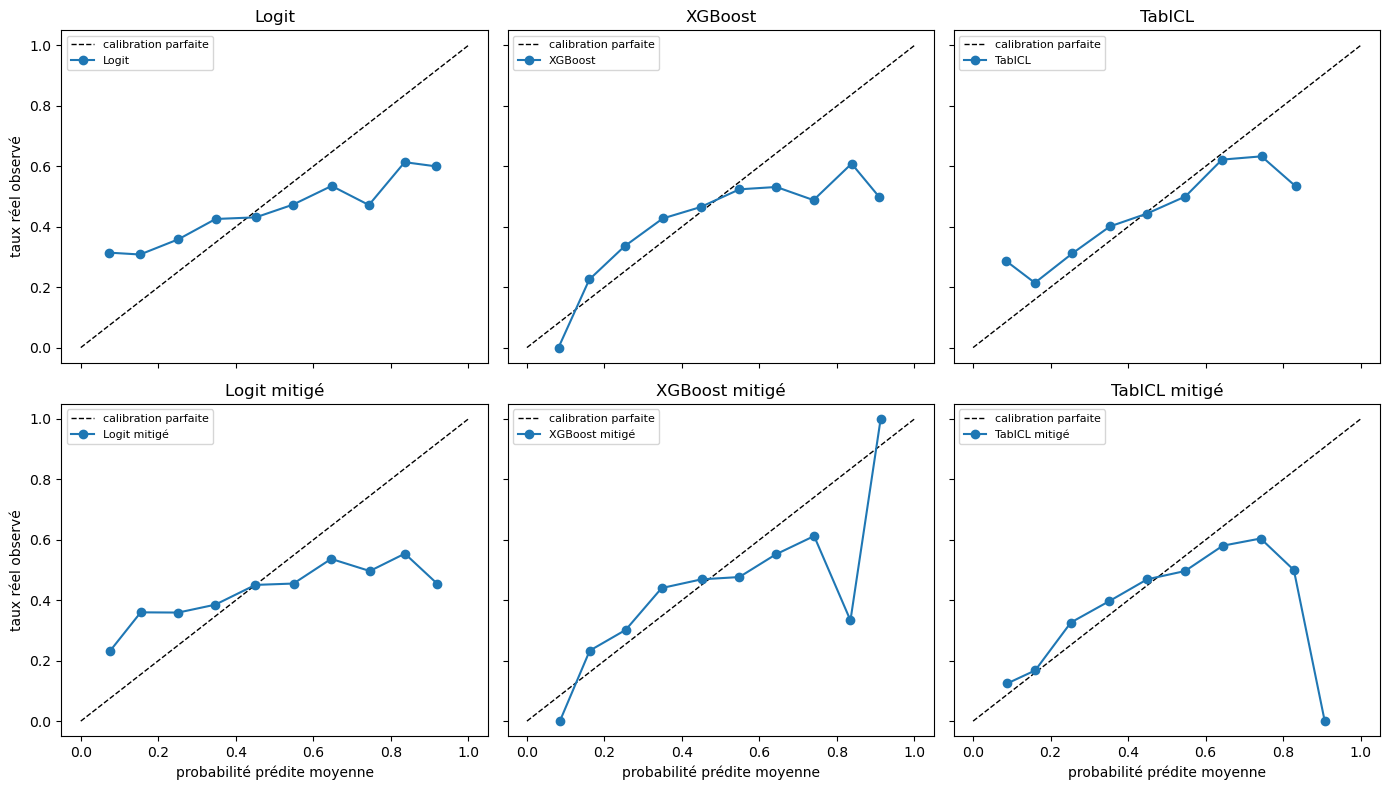

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
calibration_tables = {}
for row, names in enumerate([BASELINE_MODEL_NAMES, MITIGATED_MODEL_NAMES]):
    for ax, name in zip(axes[row], names):
        calib = calibration_table(test["dec"], test[proba_cols[name]])
        calibration_tables[name] = calib
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="calibration parfaite")
        ax.plot(calib["mean_predicted"], calib["observed_rate"], "o-", label=MODEL_LABELS[name])
        ax.set_title(MODEL_LABELS[name])
        ax.legend(fontsize=8)
    axes[row][0].set_ylabel("taux réel observé")
for ax in axes[1]:
    ax.set_xlabel("probabilité prédite moyenne")
plt.tight_layout()
plt.show()


## Partie 3 — Optimisation économique (avant la matrice de confusion de la partie 1,
pour disposer du seuil optimal)

### Hypothèses économiques

Chargées depuis `data/economic_assumptions.json` — **aucune valeur X/Y/Z en dur dans le code**,
tout passe par ce fichier. Réalignées sur les hypothèses de Max (`src/mitigation.py`,
`GAIN_TP=2, COST_FP=1, COST_FN=1`) pour la cohérence du projet.


In [5]:
assumptions = load_economic_assumptions()
X, Y, Z = assumptions["X"], assumptions["Y"], assumptions.get("Z", 0.0)
print(f"X (gain d'un oui recommandé, TP)       = {X}")
print(f"Y (coût d'un non recommandé, FP)        = {Y}")
print(f"Z (coût d'une occasion manquée, FN)     = {Z}")
print(f"Note : {assumptions['note']}")


X (gain d'un oui recommandé, TP)       = 2
Y (coût d'un non recommandé, FP)        = 1
Z (coût d'une occasion manquée, FN)     = 1
Note : Aligné sur les estimations de Max (src/mitigation.py : GAIN_TP=2, COST_FP=1, COST_FN=1) pour la cohérence du projet -- version précédente : X=2, Y=0.5, pas de Z (occasions manquées non valorisées). X = gain d'un TP (profil recommandé, dec=1). Y = coût d'un FP (profil recommandé, dec=0). Z = coût d'un FN (profil non recommandé, aurait été dec=1 -- occasion manquée, désormais valorisée symétriquement au FP comme chez Max). TN = 0 (profil non recommandé, aurait été dec=0 -- décision correcte, pas de coût). Hypothèses toujours qualitatives, non mesurées -- recherche de valeurs plus réalistes en cours.


### P&L individuel

`calculate_pnl(y_true, y_pred_proba, threshold, X, Y, Z)` : **+X** si le profil est recommandé
(`proba > threshold`) ET `dec == 1` (TP) ; **−Y** si recommandé ET `dec == 0` (FP) ; **−Z** si
**non** recommandé ET `dec == 1`, occasion manquée (FN) ; **0** sinon (TN). Le coût des occasions
manquées (Z) est **nouveau** par rapport à la première version du pipeline (Z=0) — son absence
poussait les seuils optimaux vers des valeurs dégénérées (recommander presque tout le monde).

**Simplification assumée** (documentée dans `src/performance.py` et `docs/soutenance_notes.md`) :
calculé au niveau de la décision **individuelle** (`dec`), pas du vrai match mutuel (`match` =
A ET B disent oui) — croiser deux décisions d'une même paire sortirait du cadre "un score, une
recommandation".

### Grille de seuils (0.05 à 0.95, pas 0.05), optimisée sur TRAIN via GroupKFold (5 folds sur wave)

**Limite pour TabICL (base et mitigé)** : contrairement à logit/xgb (vraiment ré-entraînés à
chaque fold), TabICL ne peut pas être ré-entraîné en local — l'optimisation réutilise les
prédictions déjà figées (un seul entraînement complet), restreintes aux indices de validation de
chaque fold. Moins rigoureux, documenté explicitement.


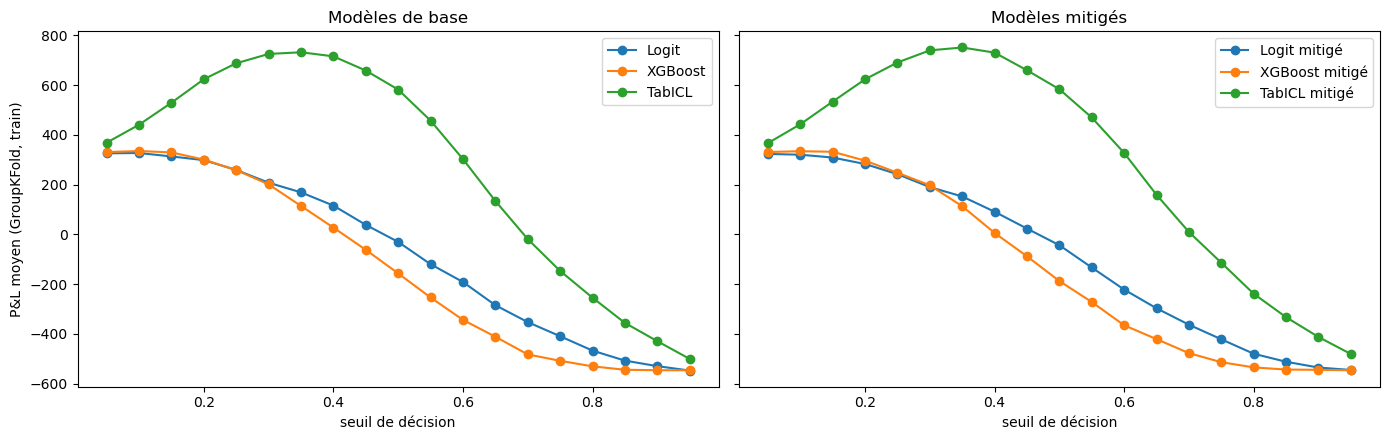

In [6]:
threshold_results = {}
for name in MODEL_NAMES:
    grid = pd.read_csv(REPORTS_DIR / f"threshold_grid_{name}.csv")
    threshold_results[name] = grid

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, names, title in zip(axes, [BASELINE_MODEL_NAMES, MITIGATED_MODEL_NAMES],
                             ["Modèles de base", "Modèles mitigés"]):
    for name in names:
        grid = threshold_results[name]
        ax.plot(grid["threshold"], grid["mean_pnl"], "o-", label=MODEL_LABELS[name])
    ax.set_xlabel("seuil de décision")
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel("P&L moyen (GroupKFold, train)")
plt.tight_layout()
plt.show()


In [7]:
summary = pd.read_csv(REPORTS_DIR / "summary_all_models.csv")
summary[["model", "optimal_threshold", "pnl_test_optimal", "pnl_test_default_05"]]


,model,optimal_threshold,pnl_test_optimal,pnl_test_default_05
0,logit,0.10,505.0,-89.0
1,xgb,0.10,536.0,-96.0
2,tabicl,0.35,375.0,-97.0
3,logit_mitigated,0.05,527.0,-83.0
4,xgb_mitigated,0.10,531.0,-163.0
5,tabicl_mitigated,0.35,391.0,-76.0


Le seuil optimal (trouvé sur train, jamais sur test) est appliqué **une seule fois** sur le test
set, comparé au P&L à seuil naïf 0.5 — le test set n'est touché qu'à ce moment précis, cohérent
avec l'architecture de validation du projet (voir `docs/soutenance_notes.md`).


### Retour Partie 1.3 — Matrice de confusion au seuil optimal

Accuracy / precision / recall / F1, au seuil optimal trouvé ci-dessus (pas à 0.5).


In [8]:
confusion_rows = []
for name in MODEL_NAMES:
    t = summary.loc[summary["model"] == name, "optimal_threshold"].iloc[0]
    m = confusion_metrics(test["dec"], test[proba_cols[name]], t)
    m["model"] = name
    confusion_rows.append(m)
pd.DataFrame(confusion_rows)[["model", "threshold", "accuracy", "precision", "recall", "f1",
                              "tn", "fp", "fn", "tp"]]


,model,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
0,logit,0.10,0.443045,0.433371,0.971903,0.599449,48,995,22,761
1,xgb,0.10,0.435926,0.431881,1.000000,0.603236,13,1030,0,783
2,tabicl,0.35,0.565717,0.495756,0.745849,0.595614,449,594,199,584
3,logit_mitigated,0.05,0.432092,0.430143,0.998723,0.601307,7,1036,1,782
4,xgb_mitigated,0.10,0.433187,0.430693,1.000000,0.602076,8,1035,0,783
5,tabicl_mitigated,0.35,0.565717,0.495812,0.756066,0.598887,441,602,191,592


## Comparaison base vs mitigé — impact économique de la fairness

Question centrale pour l'argumentaire business : **la mitigation (retrait de 4 proxies raciaux)
dégrade-t-elle la performance économique ?** Comparaison des 3 paires (logit, xgb, tabicl) sur
le P&L test au seuil optimal.


In [9]:
pairs = [("logit", "logit_mitigated"), ("xgb", "xgb_mitigated"), ("tabicl", "tabicl_mitigated")]
rows = []
for base, mitigated in pairs:
    pnl_base = summary.loc[summary["model"] == base, "pnl_test_optimal"].iloc[0]
    pnl_mit = summary.loc[summary["model"] == mitigated, "pnl_test_optimal"].iloc[0]
    auc_base = summary.loc[summary["model"] == base, "pr_auc"].iloc[0]
    auc_mit = summary.loc[summary["model"] == mitigated, "pr_auc"].iloc[0]
    rows.append({"modèle": base, "pr_auc_base": auc_base, "pr_auc_mitigé": auc_mit,
                 "delta_pr_auc": round(auc_mit - auc_base, 4),
                 "pnl_base": pnl_base, "pnl_mitigé": pnl_mit,
                 "delta_pnl": pnl_mit - pnl_base})
comparison = pd.DataFrame(rows)
comparison


,modèle,pr_auc_base,pr_auc_mitigé,delta_pr_auc,pnl_base,pnl_mitigé,delta_pnl
0,logit,0.5042,0.4922,-0.0120,505.0,527.0,22.0
1,xgb,0.5062,0.5122,0.0060,536.0,531.0,-5.0
2,tabicl,0.5445,0.5267,-0.0178,375.0,391.0,16.0


**Sur les 3 paires, aucune ne montre de dégradation économique franche de la mitigation — 2
l'améliorent même légèrement** (logit +22 de P&L optimal, tabicl +16 ; xgb -5). TabICL et logit
perdent un peu de PR-AUC après mitigation mais gagnent en P&L — cohérent avec le fait que PR-AUC
et P&L optimisent des choses différentes (discrimination globale vs décision à un seuil donné).

**Premier constat pour l'argumentaire business : la fairness ne coûte pas cher ici, et
potentiellement rien.** Réserve importante : ce sont des **points estimés sur un seul split
test** (~1800 lignes), pas encore d'intervalle de confiance — un test de significativité formel
(bootstrap apparié par session, même principe que `paired_auc_differences` dans
`reports/stability/summary.json`) a été proposé à Rémi plutôt que fait ici, pour réutiliser
directement son infrastructure de bootstrap.

**⚠️ Mise en garde sur `logit_mitigated` spécifiquement** : ce modèle cumule deux problèmes de
colinéarité que notre propre pipeline corrige mais que la mitigation de Max (entraînée sur
l'ancien schéma) n'a pas repris — `drop_first=True` non appliqué (6 colonnes de référence
piégées, `career_c_A_1` etc.) et `shar1_1_A`/`shar1_1_B` toujours présentes (colinéarité
compositionnelle). La régularisation L2 par défaut de scikit-learn absorbe le rang déficient
donc le P&L/PR-AUC ci-dessus restent probablement lisibles, mais l'interprétabilité en pâtit —
voir la section XPER-PNL plus bas, où ça se manifeste concrètement.


## Partie 2 — XPER : trois métriques (statistique, coût brut, P&L exact)

Décomposition Shapley-style de la performance par feature (Sinclair et al.) — identifie les
features qui contribuent le plus, contrairement à une importance générique (gain XGBoost,
coefficients logit) qui n'est pas directement comparable entre modèles. Calculé pour les 4
modèles refittables (`logit`, `xgb`, `logit_mitigated`, `xgb_mitigated`) — **TabICL (base et
mitigé) non calculable en local**, nécessite le vrai objet modèle appelé des centaines de fois
sur des coalitions de features masquées, pas juste des prédictions figées. Tenté sur Colab via
`colab/xper_tabicl.py`, résultat non garanti.

**⚠️ Bug vérifié dans la librairie XPER** : ses paramètres `CFP`/`CFN` sont inversés en interne
par rapport à leur docstring (`CFP` pondère en réalité les faux négatifs, `CFN` les faux
positifs) — vérifié empiriquement, documenté et corrigé dans `src/performance.py`. Sans
incidence ici car nos coûts Y et Z sont égaux (1 et 1), mais à garder en tête pour tout usage
futur à coûts asymétriques.


### 2.1 XPER-AUC — décomposition de la performance statistique


In [10]:
xper_auc_results = {}
for name in ["logit", "xgb", "logit_mitigated", "xgb_mitigated"]:
    xper_auc_results[name] = pd.read_csv(REPORTS_DIR / f"xper_auc_{name}.csv")
    print(f"--- Top 10 XPER-AUC, {MODEL_LABELS[name]} ---")
    print(xper_auc_results[name].head(10).to_string(index=False))
    print()


--- Top 10 XPER-AUC, Logit ---
      feature  xper_value  abs_xper_value
 career_c_B_8    0.089657        0.089657
    sinc3_1_A    0.084497        0.084497
    theater_A    0.066187        0.066187
   clubbing_A    0.061263        0.061263
       date_A    0.055766        0.055766
    museums_B    0.051221        0.051221
    attr3_1_B    0.033634        0.033634
career_c_A_15    0.028590        0.028590
     go_out_A    0.028274        0.028274
 abs_age_diff    0.025832        0.025832

--- Top 10 XPER-AUC, XGBoost ---
      feature  xper_value  abs_xper_value
field_cd_B_NA    0.132226        0.132226
   imprelig_A    0.048281        0.048281
    theater_A    0.045440        0.045440
 abs_age_diff    0.039287        0.039287
       date_B    0.037828        0.037828
        age_B    0.037603        0.037603
        age_A    0.036692        0.036692
 career_c_B_7    0.034991        0.034991
field_cd_A_13    0.030062        0.030062
field_cd_A_18    0.030047        0.030047

--- Top 10

**Lien avec la fairness (Max)** : on vérifie explicitement si `income_A`/`income_B` — déjà
identifiées comme proxy géographique potentiel de `race_A`/`cand_race` (ANOVA, voir
`docs/soutenance_notes.md`) — apparaissent parmi les features à forte contribution XPER.


In [11]:
for name in ["logit", "xgb", "logit_mitigated", "xgb_mitigated"]:
    top = xper_auc_results[name].head(10)
    income_in_top = top[top["feature"].str.contains("income", case=False)]
    print(f"{MODEL_LABELS[name]} : income_A/B dans le top 10 XPER-AUC -> "
          f"{'OUI : ' + ', '.join(income_in_top['feature']) if len(income_in_top) else 'non'}")


Logit : income_A/B dans le top 10 XPER-AUC -> non
XGBoost : income_A/B dans le top 10 XPER-AUC -> non
Logit mitigé : income_A/B dans le top 10 XPER-AUC -> non
XGBoost mitigé : income_A/B dans le top 10 XPER-AUC -> non


### 2.2 XPER-MC — coût de mauvaise classification brut (métrique native XPER, matrice de Max)

`eval_metric="MC"`, décompose `Y·FP + Z·FN` (CFP/CFN corrigés pour appliquer Y au FP et Z au
FN, cf. mise en garde ci-dessus). Ne modélise **pas** de récompense pour un vrai positif —
proche d'un raisonnement économique mais pas exactement notre P&L (voir 2.3).


In [12]:
xper_mc_results = {}
for name in ["logit", "xgb", "logit_mitigated", "xgb_mitigated"]:
    xper_mc_results[name] = pd.read_csv(REPORTS_DIR / f"xper_mc_{name}.csv")
    print(f"--- Top 10 XPER-MC, {MODEL_LABELS[name]} ---")
    print(xper_mc_results[name].head(10).to_string(index=False))
    print()


--- Top 10 XPER-MC, Logit ---
      feature  xper_value  abs_xper_value
        age_A    0.427325        0.427325
     amb3_1_B   -0.130746        0.130746
       date_A   -0.078057        0.078057
     fun3_1_B   -0.071310        0.071310
career_c_A_16   -0.067304        0.067304
career_c_A_11   -0.063404        0.063404
career_c_B_10   -0.059449        0.059449
field_cd_A_14   -0.058642        0.058642
 career_c_B_2   -0.058315        0.058315
 career_c_B_7   -0.056896        0.056896

--- Top 10 XPER-MC, XGBoost ---
      feature  xper_value  abs_xper_value
        age_A   -0.434895        0.434895
    imprace_A    0.214713        0.214713
   intel3_1_B   -0.164600        0.164600
field_cd_B_NA   -0.162700        0.162700
 field_cd_B_6    0.150296        0.150296
     go_out_A    0.133993        0.133993
       date_A   -0.108847        0.108847
field_cd_A_13    0.108799        0.108799
      music_A    0.097835        0.097835
   imprelig_A   -0.072934        0.072934

--- Top 10 X

### 2.3 XPER-PNL — décomposition exacte de notre vrai P&L (nouveau)

Dérivation : `P&L = X·TP − Y·FP − Z·FN`, et comme `TP = P − FN` (P = nombre de positifs réels,
constant, n'affecte aucune feature) : `P&L = X·P − (X+Z)·FN − Y·FP`. Décomposer le P&L revient
donc **exactement** (pas une approximation) à décomposer un coût de classification avec coût de
FN = (X+Z) et coût de FP = Y — implémenté dans `compute_xper_pnl()` en tenant compte du bug
CFP/CFN documenté plus haut.


In [13]:
xper_pnl_results = {}
for name in ["logit", "xgb", "logit_mitigated", "xgb_mitigated"]:
    xper_pnl_results[name] = pd.read_csv(REPORTS_DIR / f"xper_pnl_{name}.csv")
    print(f"--- Top 10 XPER-PNL, {MODEL_LABELS[name]} ---")
    print(xper_pnl_results[name].head(10).to_string(index=False))
    print()


--- Top 10 XPER-PNL, Logit ---
      feature  xper_value  abs_xper_value
        age_A    0.907584        0.907584
     amb3_1_B   -0.276044        0.276044
       date_A   -0.162326        0.162326
     fun3_1_B   -0.153594        0.153594
career_c_A_16   -0.142645        0.142645
career_c_A_11   -0.134495        0.134495
career_c_B_10   -0.126896        0.126896
 career_c_B_2   -0.125922        0.125922
 career_c_B_7   -0.123951        0.123951
field_cd_A_14   -0.123249        0.123249

--- Top 10 XPER-PNL, XGBoost ---
      feature  xper_value  abs_xper_value
        age_A   -0.963549        0.963549
    imprace_A    0.477951        0.477951
   intel3_1_B   -0.371326        0.371326
field_cd_B_NA   -0.362026        0.362026
 field_cd_B_6    0.339535        0.339535
     go_out_A    0.295134        0.295134
field_cd_A_13    0.246689        0.246689
       date_A   -0.242171        0.242171
      music_A    0.217027        0.217027
   imprelig_A   -0.160531        0.160531

--- Top 10

**⚠️ Artefact visible** : `career_c_B_1` — une des colonnes de référence piégées par l'absence
de `drop_first=True` chez Max (cf. mise en garde plus haut) — apparaît dans le top 5 XPER-PNL de
`logit_mitigated` **et** `xgb_mitigated`. Pour le logit, c'est probablement un artefact
d'encodage plutôt qu'un vrai signal économique (le modèle est sensible à la colinéarité). Pour
XGBoost, moins préoccupant — les arbres ne sont pas sensibles à la colinéarité de la même façon
— mais reste à interpréter avec prudence tant que Max n'a pas réentraîné sur le schéma courant
(`features_logit`, `drop_first=True`, `shar1_1` retirée).


## Test de robustesse : scénarios économiques alternatifs

Refait l'optimisation de seuil pour deux scénarios alternatifs (X=1/Y=1/Z=1, X=3/Y=0.3/Z=0.3),
en réécrivant **temporairement** `data/economic_assumptions.json` à chaque scénario puis en
restaurant les valeurs d'origine (`run_robustness_test`, avec `try`/`finally`) — jamais de
valeur X/Y/Z en dur dans le code, même pour ce test.


In [14]:
robustness = pd.read_csv(REPORTS_DIR / "robustness_test.csv")
robustness


,scenario,X,Y,Z,model,optimal_threshold,pnl_test_at_optimal
0,X=1/Y=1/Z=1,1,1.0,1.0,logit,0.20,-240.0
1,X=1/Y=1/Z=1,1,1.0,1.0,xgb,0.20,-191.0
2,X=1/Y=1/Z=1,1,1.0,1.0,tabicl,0.40,-275.0
3,X=1/Y=1/Z=1,1,1.0,1.0,logit_mitigated,0.20,-260.0
4,X=1/Y=1/Z=1,1,1.0,1.0,xgb_mitigated,0.15,-229.0
5,X=1/Y=1/Z=1,1,1.0,1.0,tabicl_mitigated,0.40,-254.0
6,X=3/Y=0.3/Z=0.3,3,0.3,0.3,logit,0.05,2028.3
7,X=3/Y=0.3/Z=0.3,3,0.3,0.3,xgb,0.05,2036.1
8,X=3/Y=0.3/Z=0.3,3,0.3,0.3,tabicl,0.25,1890.9
9,X=3/Y=0.3/Z=0.3,3,0.3,0.3,logit_mitigated,0.05,2034.9


**Le classement des modèles et l'ordre de grandeur du seuil optimal changent-ils entre
scénarios ?** À lire directement dans le tableau ci-dessus.


In [15]:
pivot_threshold = robustness.pivot(index="model", columns="scenario", values="optimal_threshold")
pivot_pnl = robustness.pivot(index="model", columns="scenario", values="pnl_test_at_optimal")
print("Seuil optimal par scénario :")
print(pivot_threshold.to_string())
print("\nP&L test au seuil optimal, par scénario :")
print(pivot_pnl.to_string())
print("\nClassement des modèles par scénario (meilleur P&L en premier) :")
for col in pivot_pnl.columns:
    print(f"  {col} : {pivot_pnl[col].sort_values(ascending=False).index.tolist()}")


Seuil optimal par scénario :
scenario          X=1/Y=1/Z=1  X=3/Y=0.3/Z=0.3
model                                         
logit                    0.20             0.05
logit_mitigated          0.20             0.05
tabicl                   0.40             0.25
tabicl_mitigated         0.40             0.25
xgb                      0.20             0.05
xgb_mitigated            0.15             0.05

P&L test au seuil optimal, par scénario :
scenario          X=1/Y=1/Z=1  X=3/Y=0.3/Z=0.3
model                                         
logit                  -240.0           2028.3
logit_mitigated        -260.0           2034.9
tabicl                 -275.0           1890.9
tabicl_mitigated       -254.0           1855.8
xgb                    -191.0           2036.1
xgb_mitigated          -229.0           2036.1

Classement des modèles par scénario (meilleur P&L en premier) :
  X=1/Y=1/Z=1 : ['xgb', 'xgb_mitigated', 'logit', 'tabicl_mitigated', 'logit_mitigated', 'tabicl']
  X=3/Y=0.3/

Constat inchangé par rapport à la version à 3 modèles : **le classement n'est pas stable** selon
les hypothèses de coût — à ne pas présenter comme "tel modèle est le meilleur" sans préciser
sous quelle hypothèse économique.


## Tableau récapitulatif à 6 modèles


In [16]:
summary_display = summary.copy()
summary_display


,model,pr_auc,optimal_threshold,pnl_test_optimal,pnl_test_default_05,accuracy_at_optimal,precision_at_optimal,recall_at_optimal,f1_at_optimal,top_xper_auc_features
0,logit,0.5042,0.10,505.0,-89.0,0.443,0.433,0.972,0.599,"career_c_B_8, sinc3_1_A, theater_A, clubbing_A..."
1,xgb,0.5062,0.10,536.0,-96.0,0.436,0.432,1.000,0.603,"field_cd_B_NA, imprelig_A, theater_A, abs_age_..."
2,tabicl,0.5445,0.35,375.0,-97.0,0.566,0.496,0.746,0.596,NaN
3,logit_mitigated,0.4922,0.05,527.0,-83.0,0.432,0.430,0.999,0.601,"art_A, career_c_B_2, yoga_A, career_c_A_1, fie..."
4,xgb_mitigated,0.5122,0.10,531.0,-163.0,0.433,0.431,1.000,0.602,"art_A, museums_A, career_c_B_2, field_cd_A_5, ..."
5,tabicl_mitigated,0.5267,0.35,391.0,-76.0,0.566,0.496,0.756,0.599,NaN


## Synthèse

- **PR-AUC** : les 6 modèles au-dessus de la baseline (~0.42, taux de base) mais modestement —
  cohérent avec l'AUC modeste déjà documentée (~0.59-0.60 en GroupKFold). La mitigation ne
  déplace pas fondamentalement ce constat.
- **Calibration** : à lire depuis les graphes ci-dessus — vérifier si un modèle est
  systématiquement sur/sous-confiant avant de s'appuyer sur ses probabilités pour le P&L.
- **Seuils optimaux économiques** nettement en dessous de 0.5 pour logit/xgb (base et mitigés),
  plus haut pour TabICL (~0.35) — cohérent avec le ratio de coûts (X=2/Y=1/Z=1).
- **Base vs mitigé** : aucune des 3 paires ne montre de dégradation économique franche, 2
  l'améliorent même légèrement — bon signal pour l'argumentaire business, en attente d'un test
  de significativité formel (proposé à Rémi).
- **XPER** : 3 métriques calculées pour logit/xgb (base et mitigés) — AUC (statistique), MC
  (coût brut de Max), et PNL (décomposition exacte de notre P&L, nouveau). `income_A`/`income_B`
  absentes du top 10 de tous les modèles calculables. `logit_mitigated` à lire avec la réserve
  de colinéarité documentée plus haut. TabICL (base et mitigé) non calculable en local.
- **Robustesse** : classement des modèles pas stable selon les hypothèses de coût — voir tableau
  ci-dessus.

**Réservé au(x) finaliste(s)** (pas fait, décision explicite pour tenir le calendrier) : analyse
de sensibilité complète (grille fine sur X/Y/Z, pas 2 scénarios ponctuels), et test de
significativité formel (bootstrap apparié) sur l'écart de P&L base vs mitigé.
